# Tutorial de VQGAN

En este tutorial, exploraremos VQGAN (Vector Quantized Generative Adversarial Network), una variante avanzada de las redes generativas adversarias (GANs) que combina la cuantización vectorial con técnicas de aprendizaje profundo para mejorar la generación de imágenes. A lo largo del tutorial, nos enfocaremos en entender cómo funciona VQGAN, cuál es su arquitectura y, sobre todo, el enorme potencial que tiene en tareas de generación y reconstrucción de imágenes.

En este tutorial, llevaremos a cabo dos experimentos clave:

* **Reconstrucción de imágenes:** Usaremos modelos preentrenados de VQGAN para reconstruir imágenes del Bobo, la icónica estatua de la Universidad de los Andes. Este ejercicio nos permitirá entender cómo la red procesa y reconstruye imágenes a partir de sus representaciones latentes.

* **Generación condicionada con VQGAN-CLIP:** Exploraremos las capacidades avanzadas de VQGAN al combinarlo con CLIP (Contrastive Language-Image Pretraining). Esto nos permitirá generar imágenes basadas en descripciones textuales, demostrando el poder de estos modelos en la creación de contenido personalizado y dirigido.

## Reconstrucción de imágenes

En esta sección, exploraremos cómo VQGAN es capaz de reconstruir imágenes a partir de sus representaciones latentes. La reconstrucción de imágenes es una tarea fundamental que nos permitirá entender cómo este modelo captura y comprime la información visual en un espacio latente discreto, para luego recrear la imagen original. Utilizaremos modelos preentrenados para reconstruir una imagen de la estatua del Bobo de la Universidad de los Andes. Al observar cómo el modelo reconstruye la imagen, podremos apreciar las capacidades de VQGAN en la preservación de detalles y la generación de imágenes coherentes.

### Instalar las librerías

El primer paso para trabajar con VQGAN será asegurarnos de que nuestro entorno de trabajo esté correctamente configurado. Esto implica la instalación de las librerías necesarias para ejecutar el modelo y realizar las reconstrucciones de las imágenes. Procederemos a instalar las dependencias clave y configurar el ambiente para ejecutar el código.

In [ ]:
!unzip taming_transformers.zip
!unzip Vision2Banner.zip

In [ ]:
import taming_transformers
import yaml
import torch
from omegaconf import OmegaConf
from taming_transformers.taming.models.vqgan import VQModel, GumbelVQ
from PIL import Image
import sys
import os
import PIL
from PIL import Image
from PIL import ImageDraw, ImageFont
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import zipfile
import tarfile
import os

sys.path.append(".")
torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Funciones para Cargar y Utilizar VQGAN

En este tutorial, vamos a trabajar con tres variantes de VQGAN, cada una con diferentes niveles de compresión y tamaños de "codebook" (el conjunto de códigos que representan los bloques latentes):

* **VQGAN con f=16 y un "codebook" de 1024 entradas:** Este modelo tiene una compresión de 16x por dimensión espacial, lo que significa que reduce la resolución original de la imagen en un factor de 16 en cada dimensión.

* **VQGAN con f=16 y un "codebook" más grande de 16384 entradas:** Similar al primero en cuanto a la compresión, pero con un "codebook" más grande, lo que le permite tener más variedad en los códigos latentes que puede usar para representar una imagen.

* **VQGAN con f=8 y un "codebook" de 8192 entradas:** Este modelo tiene una compresión de 8x por dimensión espacial, lo que significa que reduce la imagen menos que los anteriores, preservando más detalles, pero a costa de requerir más capacidad de procesamiento.

Los parámetros de los modelos preentrenados se encuentran comprimidos en la carpeta `logs/`. El primer paso será descomprimir estos archivos utilizando las funciones definidas a continuación. 

In [ ]:
def unzip_file(zip_file_path, extract_to_directory=None):
    if extract_to_directory is None:
        extract_to_directory = os.path.splitext(zip_file_path)[0]  # Remove .zip to create a folder
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_directory)
    print(f'Extracted {zip_file_path} to {extract_to_directory}')


# Paths to the zip files
# VQGAN with f=16 (16x compression per spatial dimension) and with a codebook with 1024 entries
configs_1 = 'logs/vqgan_imagenet_f16_1024/configs.zip'
unzip_file(configs_1, "")

# VQGAN with f=16 (16x compression per spatial dimension) and with a larger codebook (16384 entries)
configs_2 = 'logs/vqgan_imagenet_f16_16384/configs.zip'
unzip_file(configs_2, "")


# VQGAN with f=8 (8x compression per spatial dimension) and a larger codebook-size with 8192 entries
configs_3 = 'logs/vqgan_gumbel_f8/configs.zip'
unzip_file(configs_3, "")

Ahora, para cargar y utilizar estos modelos debemos declarar las funciones que nos permitan cargar los archivos de configuración y pesos de estos modelos para poder utilizarlos en la reconstrucción de imágenes. A continuación, se presentan las funciones clave que utilizaremos para este propósito:

* `load_config`: Esta función carga el archivo de configuración del modelo, el cual contiene los parámetros que definen la arquitectura de la red. Estos parámetros son esenciales para poder reconstruir correctamente el modelo.

In [ ]:
def load_config(config_path, display=False):
  config = OmegaConf.load(config_path)
  if display:
    print(yaml.dump(OmegaConf.to_container(config)))
  return config

* `load_vqgan`: Esta función toma la configuración cargada y, opcionalmente, los pesos preentrenados (checkpoint) para reconstruir el modelo VQGAN o Gumbel VQGAN, dependiendo de si usamos la variante de Gumbel.

In [ ]:
def load_vqgan(config, ckpt_path=None, is_gumbel=False):
  if is_gumbel:
    model = GumbelVQ(**config.model.params)
  else:
    model = VQModel(**config.model.params)
  if ckpt_path is not None:
    sd = torch.load(ckpt_path, map_location="cpu")["state_dict"]
    missing, unexpected = model.load_state_dict(sd, strict=False)
  return model.eval()

* `custom_to_pil`: Convierte las salidas de las imágenes generadas por el modelo (en formato tensor) en imágenes que se pueden visualizar usando PIL (Python Imaging Library).

In [ ]:
def custom_to_pil(x):
  x = x.detach().cpu()
  x = torch.clamp(x, -1., 1.)
  x = (x + 1.)/2.
  x = x.permute(1,2,0).numpy()
  x = (255*x).astype(np.uint8)
  x = Image.fromarray(x)
  if not x.mode == "RGB":
    x = x.convert("RGB")
  return x

### Carga de los Modelos Preentrenados de VQGAN
Ahora que hemos definido las funciones necesarias, procederemos a cargar los modelos preentrenados de VQGAN. Estos modelos han sido entrenados con diferentes configuraciones de compresión y tamaños de "codebook", lo que afecta tanto la capacidad de compresión como la fidelidad de reconstrucción.

* **Modelo con f=16 y codebook de 1024 entradas:** Este modelo reduce la imagen a una representación latente de tamaño $(X/16)×(X/16)$ para una imagen de entrada de $X×X$. La compresión es alta, lo que hace al modelo computacionalmente eficiente, pero esto puede afectar levemente la calidad de la reconstrucción debido a la pérdida de algunos detalles finos de la imagen original.

* **Modelo con f=16 y codebook de 16384 entradas:** Al igual que el modelo anterior, este modelo también utiliza una compresión de $16\times$, pero tiene un "codebook" más grande (16384 entradas), lo que le permite tener más flexibilidad al representar características visuales en el espacio latente. Esto mejora la capacidad del modelo para capturar variaciones sutiles en las imágenes, aunque con un aumento en la complejidad del modelo.

* **Modelo con f=8 y codebook de 8192 entradas:** Este modelo utiliza una compresión menor, reduciendo la imagen a una representación latente de $(X/8)\times(X/8)$ para una imagen de $X \times X$. El "codebook" de 8192 entradas ofrece un balance entre la capacidad de representar detalles complejos y la eficiencia computacional.

El modelo f=8 realiza una compresión menor en las imágenes, lo que resulta en una representación latente de mayor tamaño. Esto significa que es capaz de preservar más detalles y generar reconstrucciones de mayor calidad en comparación con los modelos f=16. Sin embargo, debido a la mayor longitud de la representación latente, utilizar este modelo en tareas que involucren mecanismos de atención (como transformers) es significativamente más costoso, ya que la complejidad aumenta exponencialmente con el tamaño de la secuencia.

In [ ]:
config1024 = load_config("logs/vqgan_imagenet_f16_1024/configs/model.yaml", display=False)
model1024 = load_vqgan(config1024, ckpt_path="logs/vqgan_imagenet_f16_1024/weights/last.ckpt")

config16384 = load_config("logs/vqgan_imagenet_f16_16384/configs/model.yaml", display=False)
model16384 = load_vqgan(config16384, ckpt_path="logs/vqgan_imagenet_f16_16384/weights/last.ckpt")

config32x32 = load_config("logs/vqgan_gumbel_f8/configs/model.yaml", display=False)
model32x32 = load_vqgan(config32x32, ckpt_path="logs/vqgan_gumbel_f8/weights/last.ckpt", is_gumbel=True)

### Procesamiento de las imágenes

En esta sección, utilizamos dos funciones para cargar las imagenes (`load_image_from_folder`) y realizar el preprocesamiento necesario para adecuar las imágenes al formato que los modelos esperan (`preprocess`).

La función de `preprocess` se encarga de ajustar la imagen a las dimensiones esperadas por el modelo VQGAN. Redimensiona la imagen de entrada para que se ajuste al tamaño objetivo especificado (target_image_size) y realiza un recorte central. Luego, ajusta la imagen para que este dentro del rango de `[-1, 1]`. El resultado es una imagen procesada que puede ser utilizada por el modelo VQGAN para generar su representación latente. 

In [ ]:
def load_image_from_folder(folder_path, file_name):
    # Load image from the local folder
    img_path = os.path.join(folder_path, file_name)
    return PIL.Image.open(img_path)

font = font = ImageFont.load_default()

def preprocess(img, target_image_size=256):
    s = min(img.size)
    
    if s < target_image_size:
        raise ValueError(f'min dim for image {s} < {target_image_size}')
        
    r = target_image_size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [target_image_size])
    img = torch.unsqueeze(T.ToTensor()(img), 0)
    img = 2.*img - 1
    return img

### Reconstrucción de la imagen

En esta sección, vamos a desglosar el proceso de reconstrucción de imágenes en VQGAN paso a paso, basándonos en el diagrama proporcionado. Este modelo está compuesto por tres componentes principales: el **codificador** (encoder), el proceso de **cuantización**, y el **decodificador** (decoder). Entenderemos cómo cada uno de estos componentes contribuye a transformar una imagen original en su representación latente y luego reconstruirla a partir de dicha representación.

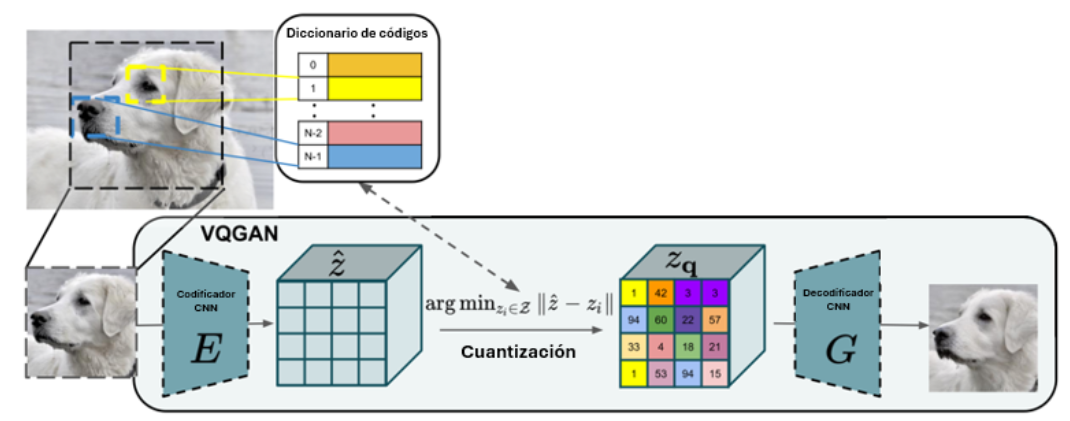

#### Definir y procesa la imagen 

Comenzamos por cargar la imagen original que será procesada por el modelo VQGAN. Primero, se utiliza la función load_image_from_folder para extraer la imagen de una carpeta local. Luego, la imagen es preprocesada mediante la función preprocess, donde se ajusta su tamaño y se normaliza para que sea compatible con el modelo. El preprocesamiento asegura que la imagen tenga las dimensiones adecuadas y esté representada como un tensor que el codificador del VQGAN puede procesar.

In [ ]:
folder_path = 'Vision2Banner'
file_name = 'IMG_1474.jpg'  

img = load_image_from_folder(folder_path, file_name)
x = preprocess(img, target_image_size=348)
print(f"Input image shape: {x.shape}")

#### El Codificador (Encoder)

El **encoder** o codificador de VQGAN es una red neuronal convolucional (CNN) que transforma la imagen original en una representación latente continua de menor resolución, denominada $\hat{z}$. Este paso es clave porque toma la imagen de entrada y extrae las características más relevantes, como texturas, bordes, colores y formas, comprimiendo esta información en un espacio de menor dimensión que facilita el procesamiento posterior.

* **Entrada**: La imagen de entrada es procesada a través de una serie de capas convolucionales que reducen la resolución de la imagen, pero aumentan la profundidad de la misma (es decir, el número de canales en la representación latente).
* **Salida**: El resultado es un tensor $\hat{z}$, que tiene menor resolución espacial pero un mayor número de canales, lo que permite representar de manera compacta la información visual importante.

En el diagrama, el codificador transforma la imagen en un cubo de características $\hat{z}$, que posteriormente será utilizado en el proceso de cuantización. El objetivo de este paso es obtener una representación comprimida y continua que capture las características esenciales de la imagen original.

In [ ]:
def encoder(x, model):
  # Llamos el codificador de nuestro modelo
  x_enc = model.encoder(x)
  return x_enc

Veamos un ejemplo utilizando el modelo model32x32, que aplica un factor de compresión de 8 y cuenta con un "codebook" de 8192 entradas. La imagen original x, con una forma de (1, 3, 348, 348), es procesada por el encoder, el cual reduce las dimensiones espaciales de la imagen según el factor de compresión. Específicamente, el tamaño original de 348 se divide entre 8, resultando en aproximadamente 43 (348/8 ≈ 43), que es el tamaño final de las dimensiones espaciales del tensor latente, redondeado al número entero más cercano. Así, la salida del encoder tiene una forma de (1, 256, 43, 43), lo que indica que las dimensiones espaciales se han reducido de 348×348 a 43×43, mientras que la profundidad del tensor ha aumentado de 3 a 256 canales.

In [ ]:
model = model32x32
x_enc = encoder(x, model)
print("Tamaño del espacio latente: ", x_enc.shape)

#### Cuantización Vectorial

El proceso de **cuantización** en VQGAN, como se muestra en el diagrama, toma la representación latente continua $\hat{z}$ producida por el codificador y la transforma en una representación discreta $\mathbf{z}_q$. Esta transformación se lleva a cabo mediante un algoritmo de cuantización vectorial, donde cada vector latente en $\hat{z}$ es mapeado al vector más cercano en un conjunto de vectores predefinidos, conocido como el diccionario de códigos o codebook. Este proceso reduce la complejidad del espacio latente, permitiendo que la información esencial de la imagen sea representada por un número limitado de códigos.

* **Entrada:** El tensor latente continuo $\hat{z}$, que proviene del codificador, pasa a través de una capa de convolución (quant_conv) para ser preparado para la cuantización.
* **Salida:** El tensor resultante es discretizado, obteniendo una versión comprimida y cuantizada $\mathbf{z}_q$, donde cada vector en el espacio latente ha sido asignado a su vector más cercano del codebook. Esta cuantización también genera una pérdida de cuantización (emb_loss), que mide cuán precisa es la asignación de cada vector.

En el diagrama, este proceso está representado por el mapeo de la representación latente $\hat{z}$ a los códigos discretos en el cubo de características $\mathbf{z}_q$, mostrando cómo cada bloque de la imagen es asignado a un código específico dentro del diccionario. Este tensor cuantizado será luego utilizado por el decodificador para reconstruir la imagen.

In [ ]:
def quantize(x, model):
    # Llamamos la función que realiza la cuantización en nuestro modelo
    x = model.quant_conv(x)
    x_quant, emb_loss, info = model.quantize(x)
    try:
        codebook = model.quantize.embedding.weight
    except:
        codebook = model.quantize.embed.weight
    return x_quant, emb_loss, info, codebook

Veamos un ejemplo de cómo el proceso de cuantización en VQGAN asigna cada porción de la representación latente a un vector en el diccionario de códigos, utilizando la salida del codificador y el modelo previamente establecido. Primero, el tensor latente comprimido `x_enc` es cuantizado utilizando el modelo predefinido, generando un espacio latente cuantizado `x_quant` y proporcionando información adicional a través de `info`, donde la segunda posición de esta variable contiene los índices del diccionario de códigos asociados a cada porción de la imagen. Esto significa que cada vector latente ha sido mapeado a su correspondiente índice en el diccionario.

Al imprimir `info[2]`, vemos los índices del diccionario para cada porción de la imagen comprimida, los cuales están organizados de acuerdo con las dimensiones espaciales del espacio latente. Para verificar esto, se imprime el índice asociado a la primera posición de la imagen comprimida, y luego se compara el vector en esa posición (`x_quant[0,:,0,0]`) con el vector correspondiente en el diccionario de códigos.

El resultado es que el vector asociado a esa porción de la imagen comprimida es efectivamente el mismo que el vector correspondiente al índice almacenado en el diccionario, lo que confirma que el proceso de cuantización asigna correctamente cada parte de la imagen a su correspondiente vector en el codebook.

In [ ]:
x_quant, emb_loss, info, codebook = quantize(x_enc, model)
print("Tamaños del espacio latente cuantizado: ", x_quant.shape)

#En la segunda posición de la variable info tenemos los indices del diccionario de codigo, asociados a cada porcion de la imagen
info[2].reshape(x_quant.shape[-1], x_quant.shape[-1])
print("Indices del diccionario de código: ", info[2], "\n con forma: ", info[2].shape)

#Indice de la primera posición de nuestra imagen comprimida
ind = int(info[2][0,0,0])

print("Vector asociado a la primera posición de nuestra imagen comprimida: ", x_quant[0,:,0,0])
print("Vector correspondiente al índice ", str(ind), " en el diccionario de códigos: ", codebook[ind])
print("El vector asociado a la primera posición de la imagen comprimida es igual al vector correspondiente al índice ", str(ind), " en el diccionario de códigos: ",  x_quant[0,:,0,0]==x_quant[0,:,0,0])

#### El Decodificador (Decoder)

El **decodificador** de VQGAN es el componente encargado de transformar la representación latente cuantizada $\mathbf{z}_q$ de nuevo en una imagen reconstruida. El decodificador es también una red neuronal convolucional (CNN), pero en lugar de reducir la dimensionalidad, su tarea es expandir la representación latente y mapearla de vuelta a una imagen de alta resolución. A medida que la información fluye a través de las capas del decodificador, los vectores discretos obtenidos durante la cuantización son transformados progresivamente en una imagen visual coherente.

* **Entrada:** El tensor $\mathbf{z}_q$, que es la representación latente cuantizada, es introducido en el decodificador. Este tensor encapsula la información clave de la imagen original, pero en un formato comprimido y discretizado.
* **Salida:** A través de varias capas convolucionales, el decodificador reconstruye la imagen en su forma original, restituyendo los detalles visuales que fueron comprimidos en la etapa de codificación.

En el diagrama, el decodificador toma el cubo de características $\mathbf{z}_q$ generado tras la cuantización y lo expande de nuevo a una imagen reconstruida que se asemeja lo más posible a la imagen original. Este proceso es fundamental para cerrar el ciclo de compresión y reconstrucción, logrando así la transformación final de la representación latente en una imagen visible.

In [ ]:
def decoder(x, model):
  # Llamos el codificador de nuestro modelo
  x_dec = model.decode(x)
  return x_dec

Finalmente, utilizemos la salida de la cuantización vectorial para ver un ejemplo de la función del decodificaro. Recordemos que estamos utilizando el modelo model32x32, que aplica un factor de compresión de 8 y cuenta con un "codebook" de 8192 entradas. Después de la cuantización, la representación latente $\mathbf{z}_q$, con una forma de (1, 256, 43, 43), es pasada al decodificador para reconstruir la imagen. Durante este proceso, el decodificador expande las dimensiones espaciales para acercarse a las de la imagen original.

Sin embargo, debido al factor de compresión, cuando la dimensión original de 348 se divide entre 8, obtenemos 43.5, que se redondea a 43 en la representación latente. Esto implica que al expandir nuevamente, el decodificador multiplicará 43 por el factor de compresión 8, lo que da una dimensión final de 344 en lugar de los 348 originales. Por lo tanto, la imagen reconstruida tiene una forma de (1, 3, 344, 344) en lugar de (1, 3, 348, 348). Este ligero cambio en las dimensiones es una consecuencia natural de los redondeos en el proceso de compresión y expansión, pero la imagen reconstruida sigue manteniendo las características visuales clave de la original.

In [ ]:
x_dec = decoder(x_quant, model)
print("Tamaño de la imagen reconstruída es: ", x_dec.shape)

#### Función de Reconstrucción Completa con VQGAN

Ahora definimos la función `reconstruct_with_vqgan`, que encapsula todo el proceso de reconstrucción de la imagen utilizando el modelo VQGAN. La función toma como entrada la imagen preprocesada x y el modelo preentrenado. Primero, la imagen es pasada por el **encoder**, que comprime la imagen original a un espacio latente continuo. Luego, la representación latente es cuantizada a través de la función `quantize`, la cual asigna los vectores latentes a su correspondiente índice en el diccionario de códigos. Finalmente, el **decoder** toma el tensor cuantizado y lo expande para generar la imagen reconstruida. Esta función devuelve la imagen final reconstruida a partir de la representación comprimida y cuantizada, cerrando así el ciclo completo del proceso en VQGAN.

In [ ]:
def reconstruct_with_vqgan(x, model):
    x_enc = encoder(x, model)
    x_quant, _, _, _ = quantize(x_enc, model)
    x_dec = decoder(x_quant, model)
    return x_dec

### Visualización de Reconstrucciones con Modelos Preentrenados

Implementaremos una serie de funciones para visualizar las reconstrucciones generadas por nuestras tres versiones distintas de VQGAN con diferentes factores de compresión y tamaños de diccionario. 

La función `stack_reconstructions` facilita la comparación visual entre la imagen original y las reconstrucciones generadas por varios modelos de VQGAN. Toma la imagen de entrada y las tres imágenes reconstruidas, las apila en una sola imagen y añade etiquetas descriptivas (títulos) sobre cada imagen. Esto permite observar las diferencias en calidad de reconstrucción entre los distintos modelos. 

In [ ]:
def stack_reconstructions(input, x0, x1, x2, titles=[]):
  assert input.size == x0.size == x1.size == x2.size
  w, h = input.size[0], input.size[1]
  img = Image.new("RGB", (4*w, h))
  img.paste(input, (0,0))
  img.paste(x0, (1*w,0))
  img.paste(x1, (2*w,0))
  img.paste(x2, (3*w,0))
  for i, title in enumerate(titles):
    ImageDraw.Draw(img).text((i*w, 0), f'{title}', (0, 0, 0), font=font, size=100) # coordinates, text, color, font
  return img

Finalmente, la función `reconstruction_pipeline_from_folder` se encarga de cargar una imagen desde una carpeta, procesarla para ajustarla al formato adecuado para VQGAN, y pasarla por los tres modelos preentrenados (con diferentes tamaños de diccionario y factores de compresión: model32x32, model16384, model1024). Luego, se utiliza la función `stack_reconstructions` previamente definida para generar una única imagen que muestre la imagen original junto a las reconstrucciones generadas por cada modelo. Esto permite una comparación visual clara entre las diferentes versiones de VQGAN, destacando cómo cada configuración afecta la calidad de la imagen reconstruida.

In [ ]:
titles=["Input", "VQGAN (f8, 8192)", "VQGAN (f16, 16384)", "VQGAN (f16, 1024)"]

def reconstruction_pipeline_from_folder(folder_path, file_name, size=320):
    # Load and preprocess the image
    img = load_image_from_folder(folder_path, file_name)
    x_vqgan = preprocess(img, target_image_size=size)
    x_vqgan = x_vqgan
    
    print(f"Input image shape: {x_vqgan.shape}")
    
    x0 = reconstruct_with_vqgan(x_vqgan, model32x32)
    x1 = reconstruct_with_vqgan(x_vqgan, model16384)
    x2 = reconstruct_with_vqgan(x_vqgan, model1024)
    
    img = stack_reconstructions(custom_to_pil(x_vqgan[0]), 
                                custom_to_pil(x0[0]), 
                                custom_to_pil(x1[0]), 
                                custom_to_pil(x2[0]), 
                                titles=titles)
    return img

# Specify the folder and image file
folder_path = 'Vision2Banner'
file_name = 'IMG_1474.jpg'  # Replace with your actual image file name
reconstruction_pipeline_from_folder(folder_path, file_name, size=384)

## Generación condicionada con VQGAN-CLIP

En la segunda parte de este tutorial, exploraremos la generación condicionada de imágenes utilizando una combinación de VQGAN y CLIP. El enfoque VQGAN-CLIP es poderoso porque permite combinar la capacidad de compresión y reconstrucción visual de VQGAN con el modelo CLIP, que asocia imágenes y textos, permitiendo generar imágenes que se ajusten a una descripción textual específica. Esto abre un mundo de posibilidades en términos de creación de contenido visual, donde un simple texto puede guiar la generación de imágenes visualmente coherentes y artísticamente interesantes.

### Instalar las librerias

Comenzaremos preparando el entorno de trabajo para la generación condicionada de imágenes utilizando VQGAN-CLIP. Instalamos e impportamos una serie de librerías esenciales que nos permitirán manejar tanto el procesamiento de imágenes como los modelos de aprendizaje profundo involucrados.

In [ ]:
!unzip CLIP

In [ ]:
import argparse
import math
from pathlib import Path
from IPython import display
from base64 import b64encode
from omegaconf import OmegaConf
from PIL import Image
from taming_transformers.taming.models import cond_transformer, vqgan
import torch
from torch import nn, optim
from torch.nn import functional as F
from torchvision import transforms
from torchvision.transforms import functional as TF
from tqdm.notebook import tqdm
import CLIP
from CLIP import clip
import torchvision.transforms as T
import numpy as np
import imageio
from PIL import ImageFile, Image
ImageFile.LOAD_TRUNCATED_IMAGES = True
from urllib.request import urlopen
import zipfile
import os
import tarfile

print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

A continuación, implementaremos una función para procesar y descomprimir los archivos ZIP que contienen los checkpoints y las configuraciones necesarias para los modelos VQGAN-CLIP.

La función `unzip_file` extrae automáticamente el contenido de los archivos comprimidos y los guarda en la misma carpeta donde se encuentran. Proporcionamos las rutas de las configuraciones, que serán descomprimidas y utilizadas para cargar los modelos preentrenados necesarios para la generación condicionada con VQGAN-CLIP. Este paso prepara el entorno con los archivos clave para ejecutar el modelo correctamente.

In [ ]:
def unzip_file(zip_file_path, extract_to_directory=None):
    if extract_to_directory is None:
        extract_to_directory = os.path.splitext(zip_file_path)[0]  # Remove .zip to create a folder
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_directory)
    print(f'Extracted {zip_file_path} to {extract_to_directory}')

#Descomprimir parametros del modelo
configs_file_path = 'VQGAN_CLIP/configs.zip'
unzip_file(configs_file_path, "VQGAN_CLIP")

### Definir funciones para le modelo VQGAN-CLIP

A continuación, definiremos funciones clave para implementar el modelo VQGAN-CLIP. Estas funciones son fundamentales para manejar tareas como la cuantización vectorial, la generación de prompts textuales, la creación de recortes de las imágenes, y la manipulación de gradientes. Estas herramientas nos permitirán generar imágenes condicionadas mediante la combinación de los poderosos modelos VQGAN y CLIP, guiando la generación a partir de descripciones textuales.

#### Funciones para procesamiento de imágenes

Las funciones de procesamiento de imágenes son esenciales para preparar adecuadamente los datos antes de ser alimentados al modelo VQGAN. Estas funciones permiten ajustar el tamaño, la resolución y la proporción de las imágenes, asegurando que mantengan la mayor calidad posible durante el redimensionado, y que se adapten a las especificaciones del modelo. Entre estas funciones, se incluyen:

* `sinc` y `lanczos`: Estas funciones calculan los valores de las funciones de interpolación sinc y Lanczos, que son ampliamente utilizadas para realizar interpolaciones suaves en el redimensionado de imágenes. Garantizan que la reducción o el aumento en el tamaño de las imágenes se haga de manera eficiente, preservando detalles importantes como los bordes y las texturas.

* `ramp`: Genera un conjunto de valores que ayudan a interpolar correctamente entre diferentes tamaños de imagen. Es especialmente útil cuando necesitamos ajustar imágenes de diferentes proporciones a un formato unificado sin distorsionar su contenido visual.

* `resample`: Es la función principal encargada de redimensionar las imágenes utilizando la interpolación Lanczos. Redimensiona las imágenes para que se ajusten a las dimensiones requeridas por el modelo, preservando la calidad y evitando artefactos indeseados.

* `resize_image`: Redimensiona las imágenes mientras mantiene la proporción original, utilizando el algoritmo LANCZOS. Esto es clave cuando trabajamos con imágenes de alta resolución y queremos evitar la pérdida de detalles importantes en el proceso de ajuste de tamaño.

In [ ]:
def sinc(x):
    return torch.where(x != 0, torch.sin(math.pi * x) / (math.pi * x), x.new_ones([]))

def lanczos(x, a):
    cond = torch.logical_and(-a < x, x < a)
    out = torch.where(cond, sinc(x) * sinc(x/a), x.new_zeros([]))
    return out / out.sum()

def ramp(ratio, width):
    n = math.ceil(width / ratio + 1)
    out = torch.empty([n])
    cur = 0
    for i in range(out.shape[0]):
        out[i] = cur
        cur += ratio
    return torch.cat([-out[1:].flip([0]), out])[1:-1]

def resample(input, size, align_corners=True):
    n, c, h, w = input.shape
    dh, dw = size
    input = input.view([n * c, 1, h, w])

    if dh < h:
        kernel_h = lanczos(ramp(dh / h, 2), 2).to(input.device, input.dtype)
        pad_h = (kernel_h.shape[0] - 1) // 2
        input = F.pad(input, (0, 0, pad_h, pad_h), 'reflect')
        input = F.conv2d(input, kernel_h[None, None, :, None])

    if dw < w:
        kernel_w = lanczos(ramp(dw / w, 2), 2).to(input.device, input.dtype)
        pad_w = (kernel_w.shape[0] - 1) // 2
        input = F.pad(input, (pad_w, pad_w, 0, 0), 'reflect')
        input = F.conv2d(input, kernel_w[None, None, None, :])

    input = input.view([n, c, h, w])
    return F.interpolate(input, size, mode='bicubic', align_corners=align_corners)

def resize_image(image, out_size):
    ratio = image.size[0] / image.size[1]
    area = min(image.size[0] * image.size[1], out_size[0] * out_size[1])
    size = round((area * ratio)**0.5), round((area / ratio)**0.5)
    return image.resize(size, Image.LANCZOS)

#### Funciones para la modificación del gradiente

El control y la manipulación de los gradientes durante el proceso de entrenamiento son esenciales para que el modelo pueda ajustarse correctamente. Las siguientes funciones permiten controlar cómo se propagan los gradientes a través de la red, evitando problemas comunes como la explosión o la desaparición del gradiente:

* `ReplaceGrad`: Esta función permite reemplazar el gradiente durante la retropropagación. Controla el flujo de gradientes en el backward pass, lo que es útil para asegurarse de que la información que retropropaga a través de la red sea la deseada, especialmente en escenarios complejos como la generación de imágenes condicionadas.

* `ClampWithGrad`: Limita los valores de entrada a un rango específico, mientras mantiene la retropropagación de los gradientes. Esto asegura que los valores no excedan ciertos límites, evitando valores extremos que puedan causar inestabilidad durante el entrenamiento, todo sin perder la capacidad de retropropagación.

In [ ]:
class ReplaceGrad(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x_forward, x_backward):
        ctx.save_for_backward(x_backward)
        return x_forward

    @staticmethod
    def backward(ctx, grad_output):
        (x_backward,) = ctx.saved_tensors
        # Pass gradient only to x_backward
        return None, grad_output

replace_grad = ReplaceGrad.apply

class ClampWithGrad(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input, min, max):
        ctx.min = min
        ctx.max = max
        ctx.save_for_backward(input)
        return input.clamp(min, max)

    @staticmethod
    def backward(ctx, grad_in):
        input, = ctx.saved_tensors
        return grad_in * (grad_in * (input - input.clamp(ctx.min, ctx.max)) >= 0), None, None

clamp_with_grad = ClampWithGrad.apply

#### Vector quantization y prompt

Las siguientes funciones son clave para conectar las imágenes con descripciones textuales, lo que permite la generación condicionada que es el núcleo de VQGAN-CLIP:

* `vector_quantize`: Esta función toma las representaciones latentes de las imágenes y las cuantiza en vectores discretos, mapeando cada vector latente al más cercano en el diccionario de códigos. Este paso es esencial en VQGAN, ya que convierte una representación continua en una representación discreta que el modelo puede manipular para generar imágenes de alta calidad.

* `Prompt`: Esta clase permite definir y manejar un prompt textual. El prompt es una instrucción que guía la generación de imágenes. La clase Prompt calcula las distancias entre la imagen generada y la instrucción textual proporcionada, permitiendo que la imagen generada se ajuste semánticamente a la descripción textual dada.

* `parse_prompt`: Esta función divide el prompt textual en sus diferentes componentes (texto, peso y valor de parada). Es útil para manejar las distintas partes de un prompt, como su peso relativo y cualquier parámetro adicional que pueda afectar el ajuste de la imagen generada.

In [ ]:
def vector_quantize(x, codebook):
    # Compute distances and get closest codes
    d = x.pow(2).sum(dim=-1, keepdim=True) + codebook.pow(2).sum(dim=1) - 2 * x @ codebook.T
    indices = d.argmin(-1)

    # Quantized vectors (non-differentiable)
    x_q = F.one_hot(indices, codebook.shape[0]).to(x.dtype) @ codebook

    # Straight-through estimator: pass forward x_q, but copy gradient from x
    return x + (x_q - x).detach()

class Prompt(nn.Module):
    def __init__(self, embed, weight=1., stop=float('-inf')):
        super().__init__()
        self.register_buffer('embed', embed)
        self.register_buffer('weight', torch.as_tensor(weight))
        self.register_buffer('stop', torch.as_tensor(stop))
    def forward(self, input):
        input_normed = F.normalize(input.unsqueeze(1), dim=2)
        embed_normed = F.normalize(self.embed.unsqueeze(0), dim=2)
        dists = input_normed.sub(embed_normed).norm(dim=2).div(2).arcsin().pow(2).mul(2)
        dists = dists * self.weight.sign()
        safe_dists = torch.maximum(dists, self.stop)
        return self.weight.abs() * replace_grad(safe_dists, dists).mean()

'''    def forward(self, input):
        input_normed = F.normalize(input.unsqueeze(1), dim=2)
        embed_normed = F.normalize(self.embed.unsqueeze(0), dim=2)
        dists = input_normed.sub(embed_normed).norm(dim=2).div(2).arcsin().pow(2).mul(2)
        dists = dists * self.weight.sign()
        return self.weight.abs() * replace_grad(dists, torch.maximum(dists, self.stop)).mean()'''

def parse_prompt(prompt):
    vals = prompt.rsplit(':', 2)
    vals = vals + ['', '1', '-inf'][len(vals):]
    return vals[0], float(vals[1]), float(vals[2])

#### Cortes aleatorios para entrenamiento

Para mejorar la capacidad de generalización del modelo, es importante que el modelo vea diferentes variaciones de las imágenes durante el entrenamiento. Aquí introducimos transformaciones aleatorias que aumentan la variabilidad de los datos de entrada:

* `MakeCutouts`: Esta clase genera múltiples cortes (o recortes) de una imagen de entrada y les aplica transformaciones aleatorias, como rotación, perspectiva, o ajuste de color. Al hacer esto, el modelo aprende a generar imágenes que sean robustas frente a pequeñas variaciones y cambios en las condiciones visuales, lo que mejora su capacidad de generalización.

In [ ]:
class MakeCutouts(nn.Module):
    def __init__(self, cut_size, cutn, cut_pow=1.):
        super().__init__()
        self.cut_size = cut_size
        self.cutn = cutn
        self.cut_pow = cut_pow

        self.augs = T.Compose([
            T.RandomAffine(degrees=15, translate=(0.1, 0.1)),
            T.RandomPerspective(distortion_scale=0.7, p=0.7),
            T.ColorJitter(hue=0.1, saturation=0.1),
            T.RandomErasing(p=0.7, scale=(0.1, 0.4), ratio=(0.3, 1 / 0.3)),
        ])
        self.noise_fac = 0.1
        self.av_pool = nn.AdaptiveAvgPool2d((self.cut_size, self.cut_size))
        self.max_pool = nn.AdaptiveMaxPool2d((self.cut_size, self.cut_size))

    def forward(self, input):
        cutouts = []
        for _ in range(self.cutn):
            cutout = (self.av_pool(input) + self.max_pool(input)) / 2
            cutouts.append(cutout)
        batch = self.augs(torch.cat(cutouts, dim=0))
        if self.noise_fac:
            facs = batch.new_empty([self.cutn, 1, 1, 1]).uniform_(0, self.noise_fac)
            batch = batch + facs * torch.randn_like(batch)
        return batch

#### Cargar el modelo VQGAN

Finalmente, para comenzar a generar imágenes, es necesario cargar el modelo preentrenado. La siguiente función carga el modelo y sus configuraciones desde un checkpoint:

* `load_vqgan_model`: Carga el modelo VQGAN según el tipo de configuración especificado. Dependiendo del tipo de modelo (VQModel, GumbelVQ o Net2NetTransformer), esta función inicializa los parámetros necesarios y carga el modelo desde un checkpoint preentrenado. Esto permite utilizar un modelo ya entrenado sin necesidad de pasar por todo el proceso de entrenamiento desde cero, lo que acelera significativamente la capacidad de generar imágenes.

In [ ]:
def load_vqgan_model(config_path, checkpoint_path):
    config = OmegaConf.load(config_path)
    
    if config.model.target == 'taming.models.vqgan.VQModel':
        model = vqgan.VQModel(**config.model.params)
        model.eval().requires_grad_(False)
        model.init_from_ckpt(checkpoint_path)
        
    elif config.model.target == 'taming.models.vqgan.GumbelVQ':
        model = vqgan.GumbelVQ(**config.model.params)
        model.eval().requires_grad_(False)
        model.init_from_ckpt(checkpoint_path)
        
    elif config.model.target == 'taming.models.cond_transformer.Net2NetTransformer':
        parent_model = cond_transformer.Net2NetTransformer(**config.model.params)
        parent_model.eval().requires_grad_(False)
        parent_model.init_from_ckpt(checkpoint_path)
        model = parent_model.first_stage_model
        
    else:
        raise ValueError(f'unknown model type: {config.model.target}')
    
    del model.loss
    return model

### Definir parámetros para la generación de imágenes con VQGAN-CLIP

Luego de definir las funciones clave para el procesamiento de imágenes, modificación de gradientes y cuantización vectorial, pasamos a establecer los parámetros de entrada que guiarán la generación de imágenes en VQGAN-CLIP. Esta sección permite personalizar tanto la descripción textual de la imagen como las características del modelo que se utilizará.

* `texts`: Define el prompt textual que describe la imagen que queremos generar.

* `width` y `height`: Especifican el tamaño de la imagen que se generará. Aquí se establece una resolución de 600x600 píxeles.

* `model`: Selecciona el modelo VQGAN preentrenado a utilizar. Se ofrece una variedad de modelos, como ImageNet, WikiArt, y COCO, cada uno ajustado para diferentes tipos de imágenes.

* `init_image`: Establece una imagen inicial que se utilizará como base para la generación. Si no se especifica, el modelo generará la imagen a partir de ruido aleatorio.

* `target_images`: Permite incluir imágenes adicionales para condicionar el resultado de la generación. Esto es útil, por ejemplo, cuando se quiere condicionar con mapas semánticos o imágenes de referencia específicas.

* `seed`: Establece la semilla aleatoria, asegurando que los resultados sean reproducibles si se desea.

* `max_iterations`: Define el número de iteraciones que se utilizarán para ajustar la imagen generada, controlando cuántas veces el modelo procesará la imagen.

Todos estos parámetros son organizados dentro de un objeto `argparse.Namespace`, que luego será utilizado para ejecutar el modelo con la configuración deseada. Esto nos permite tener control total sobre las características de la imagen y el proceso de generación.

En este caso, vamos a generar una imagen del BOBO condicionada a texto. Por ello, el prompt utilizado es **\"statue of a sitting man in Van Gogh art style\"** (\"estatua de un hombre sentado en el estilo artístico de Van Gogh\") y la imagen inicial será una imagen de la estatua del **Bobo** (`init_image`). Esto asegurará que el modelo tome tanto el estilo artístico del texto como la referencia visual de la imagen inicial para guiar el proceso de generación.

In [ ]:
# Define input parameters
texts = "statue of a sitting man in Van Gogh art style"  # param {type: "string"}
width = 600  # param {type: "number"}
height = 600  # param {type: "number"}
model = "wikiart_1024"  # param ["vqgan_imagenet_f16_16384", "vqgan_imagenet_f16_1024", "vqgan_openimages_f16_8192", "wikiart_1024", "wikiart_16384", "coco", "faceshq", "sflckr"]
images_interval = 100  # param {type: "number"}
init_image = "Vision2Banner/IMG_1150.jpg"  # param {type: "string"}
target_images = ""  # param {type: "string"}
seed = 42  # param {type: "number"}
max_iterations = 500  # param {type: "number"}

# Mapping model names
model_names = {
    "vqgan_imagenet_f16_16384": 'ImageNet 16384',
    "vqgan_imagenet_f16_1024": "ImageNet 1024",
    "vqgan_openimages_f16_8192": 'OpenImages 8912',
    "wikiart_1024": "WikiArt 1024",
    "wikiart_16384": "WikiArt 16384",
    "coco": "COCO-Stuff",
    "faceshq": "FacesHQ",
    "sflckr": "S-FLCKR"
}
name_model = model_names[model]

# Seed configuration
if seed == -1:
    seed = None
if init_image == "None":
    init_image = None

# Handle target images
if target_images == "None" or not target_images:
    target_images = []
else:
    target_images = target_images.split("|")
    target_images = [image.strip() for image in target_images]

# Handle text prompts
texts = [phrase.strip() for phrase in texts.split("|")]
if texts == ['']:
    texts = []

# Define arguments
args = argparse.Namespace(
    prompts=texts,
    image_prompts=target_images,
    noise_prompt_seeds=[],
    noise_prompt_weights=[],
    size=[width, height],
    init_image=init_image,
    init_weight=0.,
    clip_model='ViT-B/32',
    vqgan_config='VQGAN_CLIP/configs/model.yaml',
    vqgan_checkpoint='VQGAN_CLIP/ckpts/last.ckpt',
    step_size=0.1,
    cutn=32,
    cut_pow=1.,
    display_freq=images_interval,
    seed=seed,
)

### Generación de la imagen condicionada

Finalmente, llevaremos a cabo el proceso de generación de imágenes condicionadas utilizando VQGAN-CLIP. A través de una combinación de descripciones textuales y, opcionalmente, imágenes de referencia, el modelo VQGAN genera imágenes coherentes con el estilo y contenido especificado. Usaremos un modelo preentrenado de VQGAN para la síntesis de las imágenes, mientras que CLIP guiará la optimización del espacio latente a partir de los prompts textuales y visuales. A continuación, detallaremos el proceso paso a paso, desde la configuración del entorno hasta la generación de la imagen final.

#### Configuración inicial del dispositivo y modelos

En esta primera parte, configuramos el entorno de ejecución, seleccionando si el código se ejecutará en GPU o CPU, y cargamos los modelos VQGAN y CLIP. También ajustamos las dimensiones de las imágenes que se generarán y preparamos las funciones necesarias para procesar los recortes aleatorios que se usarán en el entrenamiento.

In [ ]:
# Select device for computation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Print text prompt if available
if texts:
    print('Using texts:', texts)

# Print image prompts if available
if target_images:
    print('Using image prompts:', target_images)

# Set seed for reproducibility
if args.seed is None:
    seed = torch.seed()
else:
    seed = args.seed
torch.manual_seed(seed)
print('Using seed:', seed)

# Load VQGAN model
model = load_vqgan_model(args.vqgan_config, args.vqgan_checkpoint).to(device)

# Load CLIP model
perceptor = clip.load("CLIP_model/ViT-B-32.pt", device=device, jit=False)[0].eval().requires_grad_(False).to(device)

# Get input resolution from CLIP model
cut_size = perceptor.visual.input_resolution

# Create MakeCutouts instance with the required parameters
f = 2**(model.decoder.num_resolutions - 1)  # Compute factor based on model resolution
make_cutouts = MakeCutouts(cut_size, args.cutn, cut_pow=args.cut_pow)

# Compute the number of tokens based on the image size and model factor
toksX, toksY = args.size[0] // f, args.size[1] // f
sideX, sideY = toksX * f, toksY * f

#### Inicialización del espacio latente

Dependiendo de si proporcionamos una imagen inicial o no, inicializamos el espacio latente `z`, que es el punto de partida de la imagen generada. Si se proporciona una imagen, esta será codificada en el espacio latente mediante VQGAN; si no, se inicializará de manera aleatoria.

In [ ]:
# Set the model-specific parameters for 'vqgan_openimages_f16_8192.ckpt'
if args.vqgan_checkpoint == 'vqgan_openimages_f16_8192.ckpt':
    e_dim = 256
    n_toks = model.quantize.n_embed
    z_min = model.quantize.embed.weight.min(dim=0).values[None, :, None, None]
    z_max = model.quantize.embed.weight.max(dim=0).values[None, :, None, None]
else:
    e_dim = model.quantize.e_dim
    n_toks = model.quantize.n_e
    z_min = model.quantize.embedding.weight.min(dim=0).values[None, :, None, None]
    z_max = model.quantize.embedding.weight.max(dim=0).values[None, :, None, None]

# Initialize latent vector z based on the initial image or randomly
if args.init_image:
    if 'http' in args.init_image:
        img = Image.open(urlopen(args.init_image))
    else:
        img = Image.open(args.init_image)
    pil_image = img.convert('RGB')
    pil_image = pil_image.resize((sideX, sideY), Image.LANCZOS)
    pil_tensor = TF.to_tensor(pil_image)
    z, *_ = model.encode(pil_tensor.to(device).unsqueeze(0) * 2 - 1)
else:
    one_hot = F.one_hot(torch.randint(n_toks, [toksY * toksX], device=device), n_toks).float()
    z = one_hot @ model.quantize.embedding.weight
    z = z.view([-1, toksY, toksX, e_dim]).permute(0, 3, 1, 2) 
    z = torch.rand_like(z) * 2  # Random initialization of latent vector z

# Clone original z and set z to require gradients
z_orig = z.clone()
z.requires_grad_(True)

# Set up the optimizer
opt = optim.Adam([z], lr=args.step_size)

#### Procesamiento de prompts textuales e imágenes

En este paso, procesamos los prompts textuales y las imágenes objetivo (si las hay), que guiarán la generación de la imagen. CLIP convierte estos prompts en embeddings que influenciarán el espacio latente `z`.

In [ ]:
# Normalization for CLIP model (predefined mean and std)
normalize = transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                                 std=[0.26862954, 0.26130258, 0.27577711])

# List to store the processed prompts
pMs = []

# Process text prompts
for prompt in args.prompts:
    txt, weight, stop = parse_prompt(prompt)
    embed = perceptor.encode_text(clip.tokenize(txt).to(device)).float()
    pMs.append(Prompt(embed, weight, stop).to(device))

# Process image prompts
for prompt in args.image_prompts:
    path, weight, stop = parse_prompt(prompt)
    img = Image.open(path)
    pil_image = img.convert('RGB')
    img = resize_image(pil_image, (sideX, sideY))  # Resize the image
    batch = make_cutouts(TF.to_tensor(img).unsqueeze(0).to(device))  # Make cutouts from image
    embed = perceptor.encode_image(normalize(batch)).float()  # Encode image with CLIP
    pMs.append(Prompt(embed, weight, stop).to(device))

# Process noise prompts (for noise-based embeddings)
for seed, weight in zip(args.noise_prompt_seeds, args.noise_prompt_weights):
    gen = torch.Generator().manual_seed(seed)
    embed = torch.empty([1, perceptor.visual.output_dim]).normal_(generator=gen)
    pMs.append(Prompt(embed, weight).to(device))

#### Función de síntesis y visualización

Aquí definimos las funciones necesarias para convertir el espacio latente `z` en una imagen visualizable. También incluimos una función de visualización que guarda la imagen generada en cada iteración.

In [ ]:
# Function to synthesize an image from the latent vector z
def synth(z):
    if args.vqgan_checkpoint == 'vqgan_openimages_f16_8192.ckpt':
        z_q = vector_quantize(z.movedim(1, 3), model.quantize.embed.weight).movedim(3, 1)
    else:
        z_q = vector_quantize(z.movedim(1, 3), model.quantize.embedding.weight).movedim(3, 1)
    # Decode the quantized vector and clamp the output to valid image range [0, 1]
    return model.decode(z_q).add(1).div(2)
    #return clamp_with_grad(model.decode(z_q).add(1).div(2), 0, 1)

# Function to log progress and save intermediate results
@torch.no_grad()
def checkin(i, losses):
    losses_str = ', '.join(f'{loss.item():g}' for loss in losses)
    tqdm.write(f'i: {i}, loss: {sum(losses).item():g}, losses: {losses_str}')
    
    # Generate the current output image
    out = synth(z)
    
    # Save the output as a PNG image and display it
    TF.to_pil_image(out[0].cpu()).save('progress.png')
    display.display(display.Image('progress.png'))

#### Optimización y entrenamiento

Finalmente, el ciclo de optimización ajusta el espacio latente `z` utilizando los prompts textuales y las imágenes objetivo. Este proceso se repite durante varias iteraciones hasta generar una imagen coherente.

In [ ]:
if not os.path.exists('steps'):
    os.makedirs('steps')

def ascend_txt():
    global i
    out = synth(z)
    iii = perceptor.encode_image(normalize(make_cutouts(out))).float()
    
    result = []

    if args.init_weight:
        result.append(F.mse_loss(z, torch.zeros_like(z_orig)) * ((1/torch.tensor(i*2 + 1))*args.init_weight) / 2)
    for prompt in pMs:
        result.append(prompt(iii))
    img = np.array(out.mul(255).clamp(0, 255)[0].cpu().detach().numpy().astype(np.uint8))[:,:,:]
    img = np.transpose(img, (1, 2, 0))
    imageio.imwrite('./steps/' + str(i) + '.png', np.array(img))

    return result

def train(i):
    with torch.enable_grad():
        opt.zero_grad()
        lossAll = ascend_txt()
        if i % args.display_freq == 0:
            checkin(i, lossAll)

        loss = sum(lossAll)
        loss.backward()
        opt.step()
        with torch.no_grad():
            z.clamp_(z_min, z_max)

i = 0
try:
    with tqdm() as pbar:
        while True:
            train(i)
            if i == max_iterations:
                break
            i += 1
            pbar.update()
except KeyboardInterrupt:
    pass